In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

/Users/jonathancolen/miniconda3/envs/pytorch/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/Users/jonathancolen/miniconda3/envs/pytorch/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


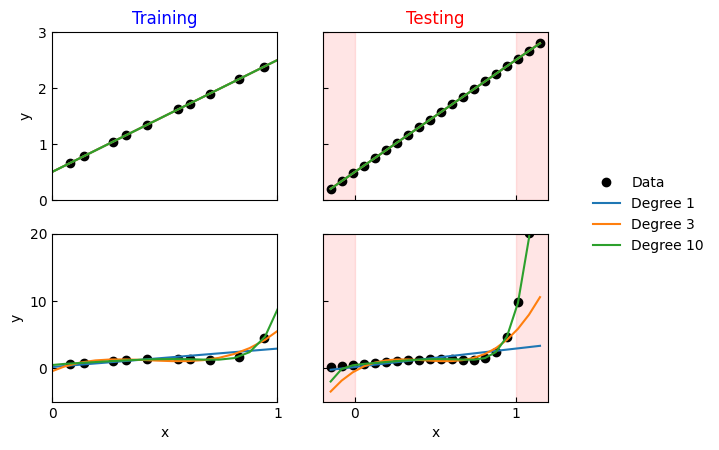

In [84]:
from numpy.polynomial import Polynomial

def plot_train_test(ax, poly, x_train, x_test, degree=[1, 3, 10]):
    y_train = poly(x_train)
    ax[0].plot(x_train, y_train, 
               linestyle='', marker='o', color='black',
               label='Data')

    ax[1].plot(x_test, poly(x_test), 
               linestyle='', marker='o', color='black',
               label='Data')

    for deg in degree:
        pdeg = Polynomial.fit(x_train, y_train, deg=deg)
        ax[0].plot(x_test, pdeg(x_test), label=f'Degree {deg}')
        ax[1].plot(x_test, pdeg(x_test), label=f'Degree {deg}')

x_train = [0.08, 0.14, 0.27, 0.33, 0.42, 0.56, 0.61, 0.70, 0.83, 0.94]
x_test = np.linspace(-0.15, 1.15, 20)

linear = Polynomial([0.5, 2])
p10 = Polynomial([0.5, 2., 0., 0., 0., -6., 0, 0, 0, 0, 12])

fig, ax = plt.subplots(2, 2, sharex='col', sharey='row')
plot_train_test(ax[0], linear, x_train, x_test)
plot_train_test(ax[1], p10, x_train, x_test)

ax[0,0].set_title('Training', color='blue')
ax[0,1].set_title('Testing', color='red')

ax[0,0].set(ylim=[0, 3], yticks=[0, 1, 2, 3])
ax[1,0].set(ylim=[-5, 20], yticks=[0, 10, 20])

for a in ax[1]:
    a.set(xticks=[0, 1], xlabel='x')

for a in ax[:, 0]:
    ylim = a.get_ylim()
    a.set(ylabel='y', xlim=[0, 1], ylim=ylim)
for a in ax[:, 1]:
    ylim = a.get_ylim()
    a.fill_betweenx(ylim, -0.2, 0, color='red', alpha=0.1, zorder=-1)
    a.fill_betweenx(ylim, 1, 1.2, color='red', alpha=0.1, zorder=-1)
    a.set(xlim=[-0.2, 1.2], ylim=ylim)

fig.legend(*ax[1,1].get_legend_handles_labels(), 
           loc='center left', bbox_to_anchor=[0.95, 0.5], framealpha=0.)

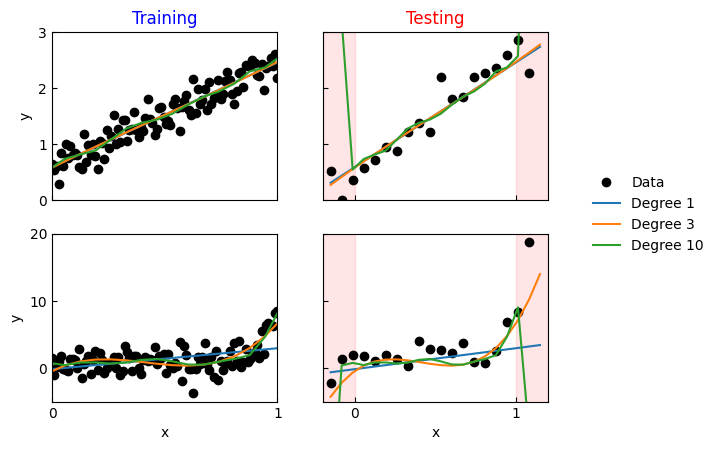

In [125]:
from numpy.polynomial import Polynomial

def plot_train_test(ax, poly, x_train, x_test, degree=[1, 3, 10], eta=0.1):
    y_train = poly(x_train) + np.random.normal(loc=0, scale=eta, size=len(x_train))
    ax[0].plot(x_train, y_train, 
               linestyle='', marker='o', color='black',
               label='Data')

    y_test = poly(x_test) + np.random.normal(loc=0, scale=eta, size=len(x_test))
    ax[1].plot(x_test, y_test, 
               linestyle='', marker='o', color='black',
               label='Data')

    for deg in degree:
        pdeg = Polynomial.fit(x_train, y_train, deg=deg)
        ax[0].plot(x_test, pdeg(x_test), label=f'Degree {deg}')
        ax[1].plot(x_test, pdeg(x_test), label=f'Degree {deg}')

x_train = np.linspace(0, 1, 100)

fig, ax = plt.subplots(2, 2, sharex='col', sharey='row')
plot_train_test(ax[0], linear, x_train, x_test, eta=0.2)
plot_train_test(ax[1], p10, x_train, x_test, eta=1.5)

ax[0,0].set_title('Training', color='blue')
ax[0,1].set_title('Testing', color='red')

ax[0,0].set(ylim=[0, 3], yticks=[0, 1, 2, 3])
ax[1,0].set(ylim=[-5, 20], yticks=[0, 10, 20])

for a in ax[1]:
    a.set(xticks=[0, 1], xlabel='x')

for a in ax[:, 0]:
    ylim = a.get_ylim()
    a.set(ylabel='y', xlim=[0, 1], ylim=ylim)
for a in ax[:, 1]:
    ylim = a.get_ylim()
    a.fill_betweenx(ylim, -0.2, 0, color='red', alpha=0.1, zorder=-1)
    a.fill_betweenx(ylim, 1, 1.2, color='red', alpha=0.1, zorder=-1)
    a.set(xlim=[-0.2, 1.2], ylim=ylim)

fig.legend(*ax[1,1].get_legend_handles_labels(), 
           loc='center left', bbox_to_anchor=[0.95, 0.5], framealpha=0.)

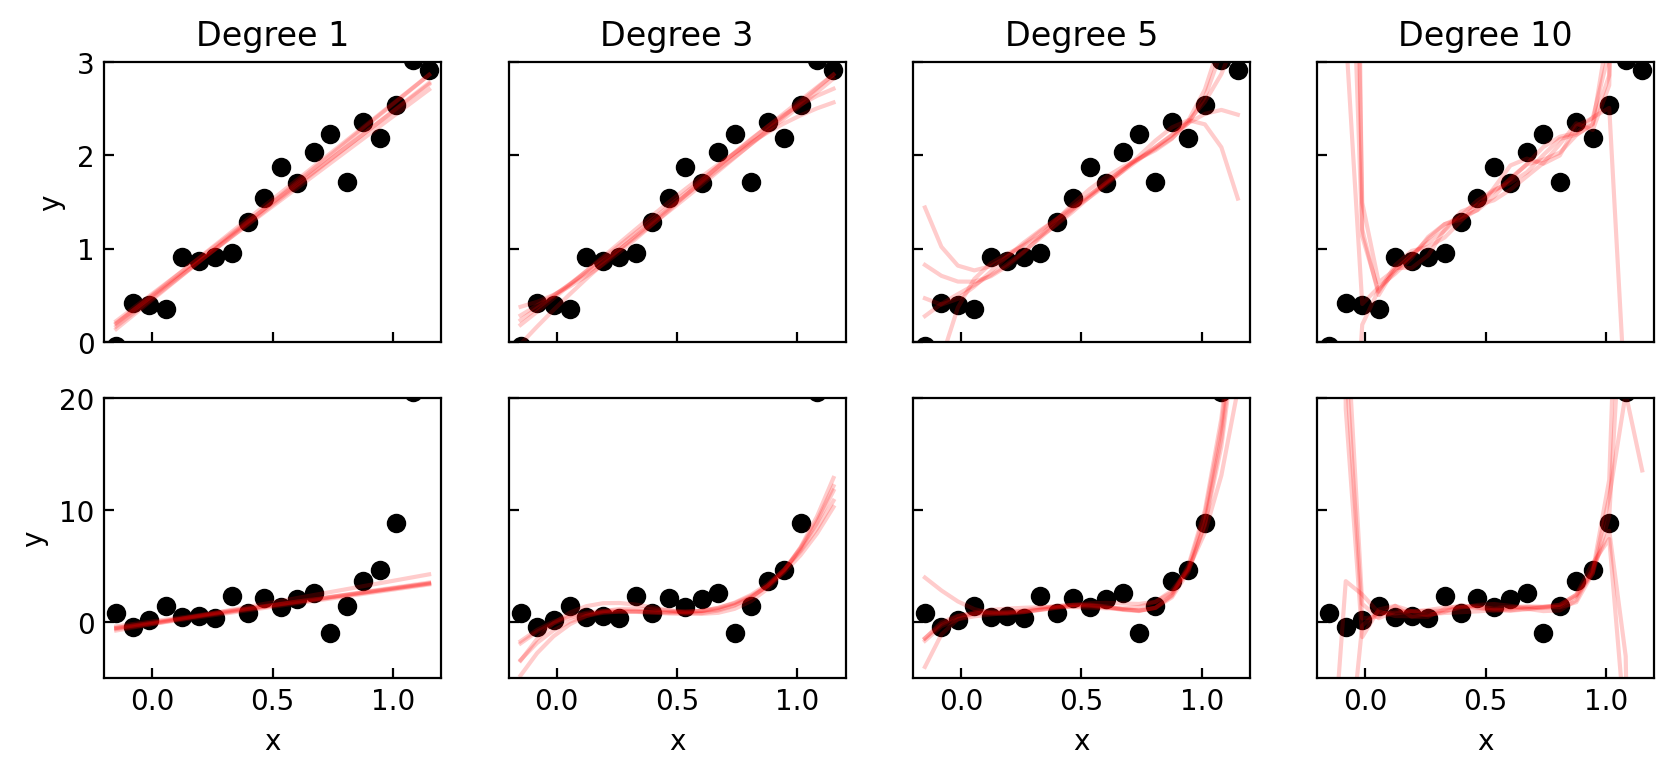

In [118]:
from numpy.polynomial import Polynomial

def plot_train_test(axes, poly, x_test, degree=[1, 3, 5, 10], eta=0.1, title=False):
    y_test = poly(x_test) + np.random.normal(loc=0, scale=eta, size=len(x_test))

    for ax, deg in zip(axes, degree):
        ax.plot(x_test, y_test, 
                linestyle='', marker='o', color='black',
                label='Test')
        for ii in range(5):
            x_train = np.random.uniform(size=100)
            y_train = poly(x_train) + np.random.normal(loc=0, scale=eta, size=len(x_train))
            pdeg = Polynomial.fit(x_train, y_train, deg=deg)
            ax.plot(x_test, pdeg(x_test), color='red', alpha=0.2)
        if title:
            ax.set(title=f'Degree {deg}')

fig, ax = plt.subplots(2, 4, figsize=(10, 4), dpi=200, sharex=True, sharey='row')
plot_train_test(ax[0], linear, x_test, eta=0.2, title=True)
plot_train_test(ax[1], p10, x_test, eta=1.)

ax[0,0].set(ylim=[0, 3], yticks=[0, 1, 2, 3])
ax[1,0].set(ylim=[-5, 20], yticks=[0, 10, 20])

for a in ax[1]:
    a.set(xlabel='x')

for a in ax[:, 0]:
    a.set(ylabel='y', xlim=[0, 1])
for a in ax[:, 1]:
    a.set(xlim=[-0.2, 1.2])